<a href="https://colab.research.google.com/github/beingdeveloper21/mini_project/blob/main/CarPricePredictionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [2]:
#loading the data from csv file to pandas DataFrame
car_dataset=pd.read_csv('/content/car data.csv')

In [3]:
#ptint the first 5 rows of the dataset
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
#checking the number of rows and colummns
car_dataset.shape

(301, 9)

In [5]:
#getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
#checking the number of missing values
car_dataset.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
#checking the distribution of categorical data
print(car_dataset.Fuel_Type.value_counts())
print(car_dataset.Seller_Type.value_counts())
print(car_dataset.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


Encoding the categorical data

In [8]:
#encoding 'Fuel_Type' column
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
#encoding 'Seller_Type' column
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
#3ncoding 'Transmission' column
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipykernel_215/879780640.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)
/tmp/ipykernel_215/879780640.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)
/tmp/ipykernel_215/879780640.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)

In [9]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


Splitting the data into Target Column and Feature Column

In [10]:
X=car_dataset.drop(['Car_Name','Selling_Price'],axis=1)
Y=car_dataset['Selling_Price']

In [11]:
print(X)

     Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1        0  
2        0  
3        0 

In [12]:
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


Splitting into training and testing data

In [13]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1,random_state=2)

Model Training

1. Linear Regression

In [14]:
#loading the linear regression model
lin_reg_model=LinearRegression()

In [15]:
lin_reg_model.fit(X_train,Y_train)

LinearRegression()

Model Evaluation

In [16]:
#prediction on training data
training_data_prediction=lin_reg_model.predict(X_train)

In [17]:
#R squared error
error_score=metrics.r2_score(Y_train,training_data_prediction)
print("R squared error : ",error_score)

R squared error :  0.8799451660493711


In [100]:
from sklearn.model_selection import GridSearchCV
lin_model = LinearRegression()
param_grid = {
    "fit_intercept": [True, False]
}
grid_lin = GridSearchCV(
    lin_model,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_lin.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=LinearRegression(),
             param_grid={'fit_intercept': [True, False]}, scoring='r2')

In [101]:
best_lin = grid_lin.best_estimator_

print("Best Parameters:", grid_lin.best_params_)

Best Parameters: {'fit_intercept': True}


In [102]:
y_pred_lin = best_lin.predict(X_test)

print("R2:", r2_score(Y_test, y_pred_lin))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_lin)))

R2: 0.8365766715027051
RMSE: 1.4663321311979867


In [103]:
from sklearn.model_selection import cross_validate
scores = cross_validate(
    best_lin,
    X,
    Y,
    cv=5,
    scoring=("r2","neg_mean_squared_error","neg_mean_absolute_error")
)
lr_rmse_cv = np.sqrt(-scores["test_neg_mean_squared_error"]).mean()
lr_mae_cv = (-scores["test_neg_mean_absolute_error"]).mean()
lr_r2_cv = scores["test_r2"].mean()
print("CV RMSE:", lr_rmse_cv)
print("CV MAE:", lr_mae_cv)
print("CV R2:", lr_r2_cv)

CV RMSE: 2.084435281004892
CV MAE: 1.4769625669574133
CV R2: -18.31025978320942


Visualize the actual prices and predicted prices

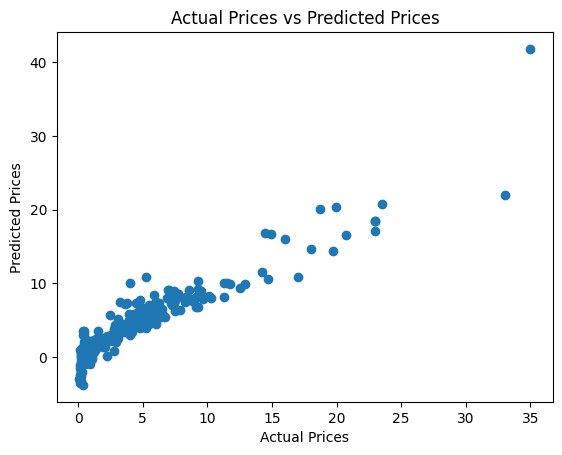

In [18]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [19]:
#prediction on test data
test_data_prediction=lin_reg_model.predict(X_test)

In [20]:
# R squared error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print("R squared error : ",error_score)

R squared error :  0.8365766715027051


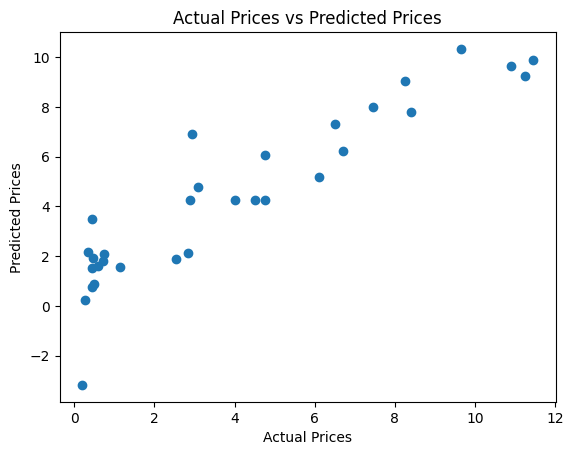

In [21]:
plt.scatter(Y_test,test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

2.Lasso Regression

In [22]:
#loading the Lasso Regression Model
lass_reg_model=Lasso()

In [23]:
lass_reg_model.fit(X_train,Y_train)

Lasso()

In [24]:
#prediction on training data
training_data_prediction=lass_reg_model.predict(X_train)

In [25]:
#R squared error
error_score=metrics.r2_score(Y_train,training_data_prediction)
print("R squared error : ",error_score)

R squared error :  0.8427856123435794


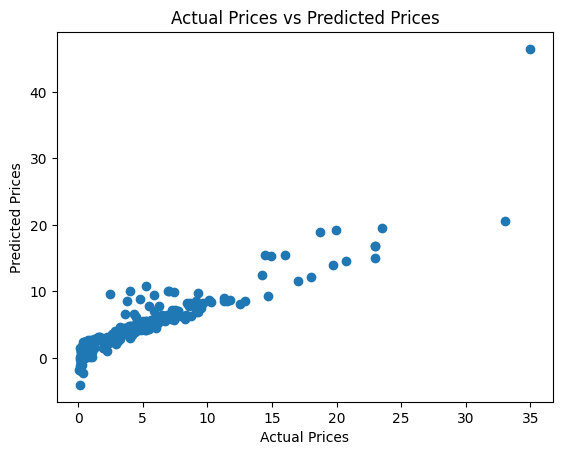

In [26]:
plt.scatter(Y_train,training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [27]:
#prediction on test data
test_data_prediction=lass_reg_model.predict(X_test)

In [28]:
#R squared error
error_score=metrics.r2_score(Y_test,test_data_prediction)
print("R squared error : ",error_score)

R squared error :  0.8709167941173195


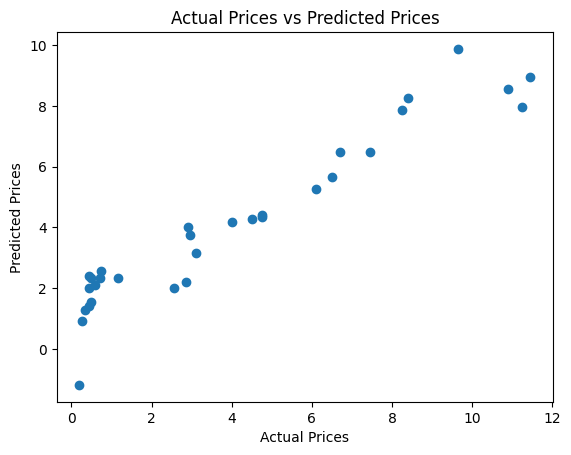

In [29]:
plt.scatter(Y_test,test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [104]:
lasso = Lasso()
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}
grid_lasso = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring="r2"
)
grid_lasso.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

In [105]:
best_lasso = grid_lasso.best_estimator_
print("Best Parameters:", grid_lasso.best_params_)

Best Parameters: {'alpha': 0.001}


In [106]:
y_pred_lasso = best_lasso.predict(X_test)

print("R2:", r2_score(Y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_lasso)))

R2: 0.8372321023089841
RMSE: 1.4633887178221812


In [107]:
scores = cross_validate(
    best_lasso,
    X,
    Y,
    cv=5,
    scoring=("r2","neg_mean_squared_error","neg_mean_absolute_error")
)

lasso_rmse_cv = np.sqrt(-scores["test_neg_mean_squared_error"]).mean()
lasso_mae_cv = (-scores["test_neg_mean_absolute_error"]).mean()
lasso_r2_cv = scores["test_r2"].mean()

print("CV RMSE:", lasso_rmse_cv)
print("CV MAE:", lasso_mae_cv)
print("CV R2:", lasso_r2_cv)

CV RMSE: 2.0836920136131543
CV MAE: 1.476167968431516
CV R2: -18.310688120785642


In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

In [31]:
rf_model = RandomForestRegressor(random_state=42)

In [32]:
rf_model.fit(X_train,Y_train)

RandomForestRegressor(random_state=42)

In [33]:
rf_pred_train=rf_model.predict(X_train)

In [34]:
rf_r2 = r2_score(Y_train, rf_pred_train)
rf_mae = mean_absolute_error(Y_train, rf_pred_train)
rf_rmse = np.sqrt(mean_squared_error(Y_train, rf_pred_train))
print(rf_r2)
print(rf_mae)
print(rf_rmse)

0.9856337653136535
0.24359037037037023
0.624490572712997


In [35]:
rf_pred_test = rf_model.predict(X_test)

In [36]:
rf_r2 = r2_score(Y_test, rf_pred_test)
rf_mae = mean_absolute_error(Y_test, rf_pred_test)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_pred_test))
print(rf_r2)
print(rf_mae)
print(rf_rmse)

0.9805517643053386
0.3423
0.50584263363224


In [37]:
from sklearn.model_selection import cross_validate
import numpy as np

scores = cross_validate(
    rf_model,
    X,
    Y,
    cv=5,
    scoring=('r2', 'neg_mean_squared_error', 'neg_mean_absolute_error')
)

r2_scores = scores['test_r2']
mse_scores = -scores['test_neg_mean_squared_error']
mae_scores = -scores['test_neg_mean_absolute_error']

rmse_scores = np.sqrt(mse_scores)

print("R2 Scores:", r2_scores)
print("MAE Scores:", mae_scores)
print("RMSE Scores:", rmse_scores)

print("Average MAE:", mae_scores.mean())
print("Average RMSE:", rmse_scores.mean())
print("Average R2 Score:", r2_scores.mean())

R2 Scores: [ 0.96455877  0.78028318 -1.59352418  0.94989275  0.75646893]
MAE Scores: [0.60869508 1.946005   0.265645   0.52302667 0.89207667]
RMSE Scores: [0.82569293 3.80074898 0.29514329 0.72948457 1.19225786]
Average MAE: 0.8470896830601096
Average RMSE: 1.3686655254077418
Average R2 Score: 0.3715358906361204


In [112]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [113]:
best_rf = grid_search.best_estimator_

In [114]:
from sklearn.model_selection import cross_validate
import numpy as np

scores = cross_validate(
    best_rf,
    X,
    Y,
    cv=5,
    scoring=("r2", "neg_mean_squared_error", "neg_mean_absolute_error")
)

rf_rmse_cv = np.sqrt(-scores["test_neg_mean_squared_error"]).mean()
rf_mae_cv = (-scores["test_neg_mean_absolute_error"]).mean()
rf_r2_cv = scores["test_r2"].mean()

print("CV Average RMSE:", rf_rmse_cv)
print("CV Average MAE:", rf_mae_cv)
print("CV Average R2:", rf_r2_cv)

CV Average RMSE: 1.3597473445173605
CV Average MAE: 0.8422802094717671
CV Average R2: 0.33923208900013435


In [45]:
!pip install xgboost

In [46]:
import xgboost as xgb
from xgboost import XGBRegressor

In [63]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, Y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [64]:
y_pred_xgb = xgb_model.predict(X_test)

In [65]:
mae = mean_absolute_error(Y_test, y_pred_xgb)
mse = mean_squared_error(Y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred_xgb)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.3339663956819042
RMSE: 0.49538409519918863
R2 Score: 0.9813476538159798


In [66]:
scores = cross_validate(
    xgb_model,
    X,
    Y,
    cv=5,
    scoring=("r2","neg_mean_squared_error","neg_mean_absolute_error")
)

rmse_scores = np.sqrt(-scores["test_neg_mean_squared_error"])
mae_scores = -scores["test_neg_mean_absolute_error"]
r2_scores = scores["test_r2"]

print("Average RMSE:", rmse_scores.mean())
print("Average MAE:", mae_scores.mean())
print("Average R2:", r2_scores.mean())

Average RMSE: 1.4493743637395693
Average MAE: 0.8651037729281139
Average R2: 0.5545568976372454


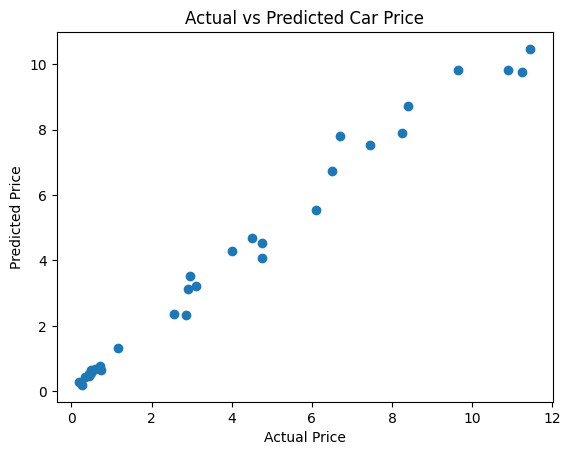

In [67]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, y_pred_xgb)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()

In [68]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [69]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=4, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=500,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [200, 300, 500],
                         'subsample': [0.8, 1]},
             scoring='r2', verbose=2)

In [70]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'colsample_bytree': 1, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [71]:
best_xgb = grid_search.best_estimator_

In [72]:
y_pred_best = best_xgb.predict(X_test)

print("MAE:", mean_absolute_error(Y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_best)))
print("R2:", r2_score(Y_test, y_pred_best))

MAE: 0.3346508068038571
RMSE: 0.4429606778928124
R2: 0.9850864958460129


In [117]:
scores = cross_validate(
    best_xgb,
    X,
    Y,
    cv=5,
    scoring=("r2","neg_mean_squared_error","neg_mean_absolute_error")
)

rmse_scores = np.sqrt(-scores["test_neg_mean_squared_error"])
mae_scores = -scores["test_neg_mean_absolute_error"]
r2_scores = scores["test_r2"]
xgb_rmse_cv = rmse_scores.mean()
xgb_mae_cv = mae_scores.mean()
xgb_r2_cv = r2_scores.mean()
print("CV Average RMSE:", rmse_scores.mean())
print("CV Average MAE:", mae_scores.mean())
print("CV Average R2:", r2_scores.mean())

CV Average RMSE: 1.3497977295310561
CV Average MAE: 0.8122691693269978
CV Average R2: 0.6461824314901042


In [82]:
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, Y_train)
y_pred_dt = dt_model.predict(X_test)
print("R2:", r2_score(Y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_dt)))

R2: 0.9525784699755273
RMSE: 0.7898836173970555


In [75]:
param_grid = {
    "max_depth": [3,4,5,6,7,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": [None,"sqrt","log2"]
}

grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_dt.fit(X_train, Y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 4, 5, 6, 7, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2', verbose=2)

In [76]:
print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [77]:
best_dt = grid_dt.best_estimator_

In [78]:
y_pred_best_dt = best_dt.predict(X_test)

print("R2:", r2_score(Y_test, y_pred_best_dt))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_best_dt)))

R2: 0.9301898761611859
RMSE: 0.9583729109265395


In [109]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    best_dt,
    X,
    Y,
    cv=5,
    scoring=("r2","neg_mean_squared_error","neg_mean_absolute_error")
)

rmse_scores = np.sqrt(-scores["test_neg_mean_squared_error"])
mae_scores = -scores["test_neg_mean_absolute_error"]
r2_scores = scores["test_r2"]
dt_rmse_cv = rmse_scores.mean()
dt_mae_cv = mae_scores.mean()
dt_r2_cv = r2_scores.mean()

print("CV Average RMSE:", rmse_scores.mean())
print("CV Average MAE:", mae_scores.mean())
print("CV Average R2:", r2_scores.mean())

CV Average RMSE: 2.0130064292065506
CV Average MAE: 1.209322752190129
CV Average R2: 0.13661128576811044


In [83]:
from sklearn.ensemble import AdaBoostRegressor
ada_model = AdaBoostRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_model.fit(X_train, Y_train)

AdaBoostRegressor(learning_rate=0.1, n_estimators=200, random_state=42)

In [84]:
y_pred_ada = ada_model.predict(X_test)

In [85]:
print("R2:", r2_score(Y_test, y_pred_ada))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_ada)))

R2: 0.9515993201168141
RMSE: 0.7979966285023545


In [86]:
from sklearn.ensemble import AdaBoostRegressor
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
    "loss": ["linear", "square", "exponential"]
}
grid_ada = GridSearchCV(
    estimator=AdaBoostRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)
grid_ada.fit(X_train, Y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5, estimator=AdaBoostRegressor(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.5],
                         'loss': ['linear', 'square', 'exponential'],
                         'n_estimators': [100, 200, 300, 500]},
             scoring='r2', verbose=2)

In [87]:
print("Best Parameters:", grid_ada.best_params_)

Best Parameters: {'learning_rate': 0.5, 'loss': 'linear', 'n_estimators': 200}


In [88]:
best_ada = grid_ada.best_estimator_

In [89]:
y_pred_best_ada = best_ada.predict(X_test)
print("R2:", r2_score(Y_test, y_pred_best_ada))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_best_ada)))

R2: 0.945101558365035
RMSE: 0.8498755469437737


In [116]:
scores = cross_validate(
    best_ada,
    X,
    Y,
    cv=5,
    scoring=("r2","neg_mean_squared_error","neg_mean_absolute_error")
)
ada_rmse_cv = rmse_scores.mean()
ada_mae_cv = mae_scores.mean()
ada_r2_cv = r2_scores.mean()
rmse_scores = np.sqrt(-scores["test_neg_mean_squared_error"])
mae_scores = -scores["test_neg_mean_absolute_error"]
r2_scores = scores["test_r2"]

print("CV Average RMSE:", rmse_scores.mean())
print("CV Average MAE:", mae_scores.mean())
print("CV Average R2:", r2_scores.mean())

CV Average RMSE: 1.7702621638230684
CV Average MAE: 1.1974536744839421
CV Average R2: -3.9514694307173146


In [91]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, Y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [92]:
y_pred_gbr = gbr_model.predict(X_test)

In [93]:
print("R2:", r2_score(Y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_gbr)))

R2: 0.9833908104485534
RMSE: 0.4674654802293594


In [94]:
scores = cross_validate(
    gbr_model,
    X,
    Y,
    cv=5,
    scoring=("r2","neg_mean_squared_error","neg_mean_absolute_error")
)

rmse_scores = np.sqrt(-scores["test_neg_mean_squared_error"])
mae_scores = -scores["test_neg_mean_absolute_error"]
r2_scores = scores["test_r2"]

print("CV RMSE:", rmse_scores.mean())
print("CV MAE:", mae_scores.mean())
print("CV R2:", r2_scores.mean())

CV RMSE: 1.3233515440242514
CV MAE: 0.7958904545759268
CV R2: 0.42460501697184505


In [95]:
gbr = GradientBoostingRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1]
}

grid_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_gbr.fit(X_train, Y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1]},
             scoring='r2', verbose=2)

In [96]:
print("Best Parameters:", grid_gbr.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [97]:
best_gbr = grid_gbr.best_estimator_

In [98]:
y_pred_best_gbr = best_gbr.predict(X_test)
print("R2:", r2_score(Y_test, y_pred_best_gbr))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred_best_gbr)))

R2: 0.9839313039417068
RMSE: 0.45979648131389006


In [115]:
scores = cross_validate(
    best_gbr,
    X,
    Y,
    cv=5,
    scoring=("r2", "neg_mean_squared_error", "neg_mean_absolute_error")
)
gbr_rmse_cv = rmse_scores.mean()
gbr_mae_cv = mae_scores.mean()
gbr_r2_cv = r2_scores.mean()

rmse_scores = np.sqrt(-scores["test_neg_mean_squared_error"])
mae_scores = -scores["test_neg_mean_absolute_error"]
r2_scores = scores["test_r2"]

print("CV Average RMSE:", rmse_scores.mean())
print("CV Average MAE:", mae_scores.mean())
print("CV Average R2:", r2_scores.mean())

CV Average RMSE: 1.2589087395455842
CV Average MAE: 0.7508452256043613
CV Average R2: 0.20600078178417486


In [118]:
results = {
    "Linear Regression": [lr_rmse_cv, lr_mae_cv, lr_r2_cv],
    "Lasso Regression": [lasso_rmse_cv, lasso_mae_cv, lasso_r2_cv],
    "Decision Tree": [dt_rmse_cv, dt_mae_cv, dt_r2_cv],
    "Random Forest": [rf_rmse_cv, rf_mae_cv, rf_r2_cv],
    "AdaBoost": [ada_rmse_cv, ada_mae_cv, ada_r2_cv],
    "Gradient Boosting": [gbr_rmse_cv, gbr_mae_cv, gbr_r2_cv],
    "XGBoost": [xgb_rmse_cv, xgb_mae_cv, xgb_r2_cv]
}

In [119]:
import pandas as pd

comparison_df = pd.DataFrame(
    results,
    index=["RMSE", "MAE", "R2"]
).T

comparison_df

,RMSE,MAE,R2
Linear Regression,2.084435,1.476963,-18.310260
Lasso Regression,2.083692,1.476168,-18.310688
Decision Tree,2.013006,1.209323,0.136611
Random Forest,1.359747,0.842280,0.339232
AdaBoost,1.258909,0.750845,0.206001
Gradient Boosting,2.013006,1.209323,0.136611
XGBoost,1.349798,0.812269,0.646182


In [120]:
comparison_df = comparison_df.sort_values("R2", ascending=False)
comparison_df

,RMSE,MAE,R2
XGBoost,1.349798,0.812269,0.646182
Random Forest,1.359747,0.842280,0.339232
AdaBoost,1.258909,0.750845,0.206001
Decision Tree,2.013006,1.209323,0.136611
Gradient Boosting,2.013006,1.209323,0.136611
Linear Regression,2.084435,1.476963,-18.310260
Lasso Regression,2.083692,1.476168,-18.310688


In [121]:
best_model = comparison_df.index[0]
print("Best Model Based on Cross Validation:", best_model)

Best Model Based on Cross Validation: XGBoost


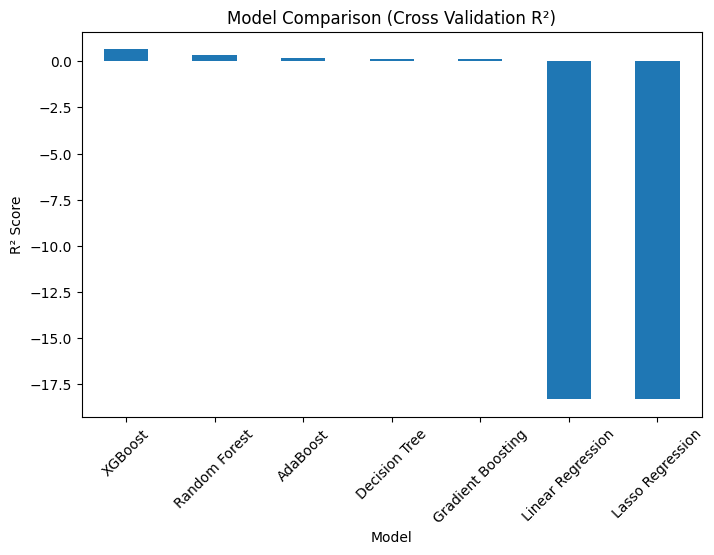

In [122]:
import matplotlib.pyplot as plt

comparison_df["R2"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison (Cross Validation R²)")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()

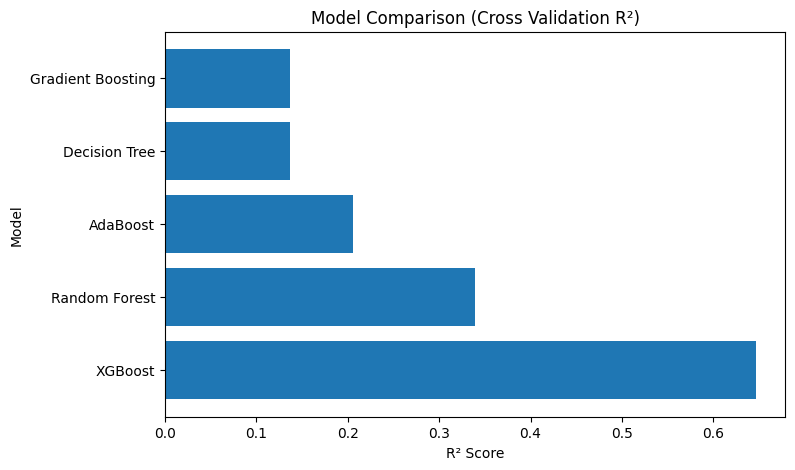

In [123]:
import matplotlib.pyplot as plt

# filter out extreme negative R2
filtered_df = comparison_df[comparison_df["R2"] > -1]

plt.figure(figsize=(8,5))
plt.barh(filtered_df.index, filtered_df["R2"])

plt.title("Model Comparison (Cross Validation R²)")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

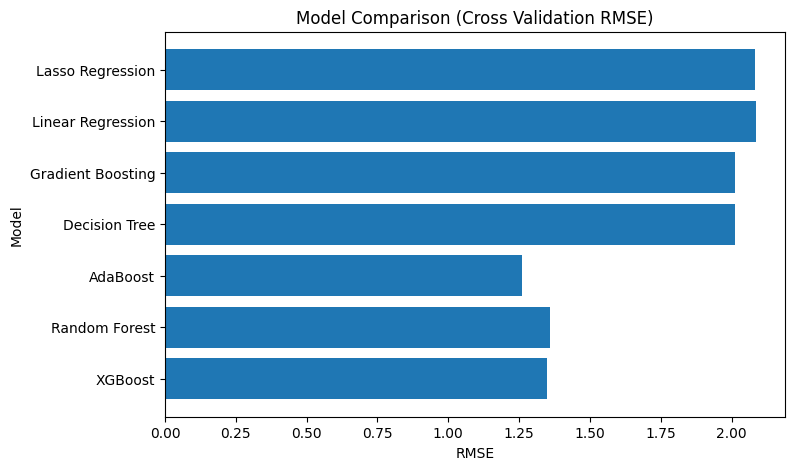

In [124]:
plt.figure(figsize=(8,5))
plt.barh(comparison_df.index, comparison_df["RMSE"])
plt.title("Model Comparison (Cross Validation RMSE)")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

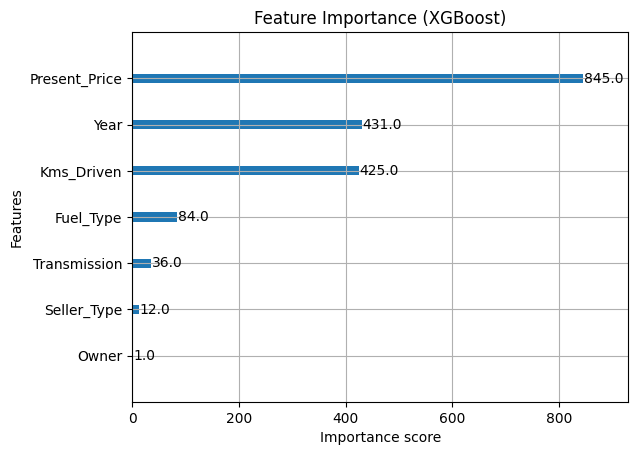

In [125]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(best_xgb)
plt.title("Feature Importance (XGBoost)")
plt.show()

In [126]:
import joblib

joblib.dump(best_xgb, "car_price_model.pkl")

['car_price_model.pkl']

In [127]:
loaded_model = joblib.load("car_price_model.pkl")

prediction = loaded_model.predict(X_test[:1])

print("Predicted price:", prediction)

Predicted price: [9.578663]


Several regression models including Linear Regression, Lasso Regression, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, and XGBoost were trained to predict car prices.
Hyperparameter tuning was performed using GridSearchCV, and models were evaluated using 5-fold cross-validation with RMSE, MAE, and R² metrics.

The comparison results show that XGBoost achieved the best performance, followed by Random Forest and AdaBoost. Linear models performed poorly due to the nonlinear relationships in the dataset.

Therefore, XGBoost was selected as the final model for car price prediction.